# 6. Packages and Dataset Understanding

## Objective
This practical introduces NumPy, Pandas, Matplotlib and Seaborn, and demonstrates how to load and inspect a real-world dataset using Pandas.

**Dataset:** Titanic passenger dataset  
**Repository section:** `EDA/`

The Titanic dataset contains passenger information such as age, passenger class, fare, sex and survival status. Run the cells from top to bottom.

## 1. Installing the Required Packages

Python packages provide reusable functionality. `%pip` installs packages into the environment used by the current Jupyter kernel.

In [1]:
%pip install numpy pandas matplotlib seaborn

## 2. Importing the Libraries

- **NumPy:** Numerical computing and arrays.
- **Pandas:** Loading, organizing and analyzing tabular data.
- **Matplotlib:** Creating and customizing charts.
- **Seaborn:** Statistical visualizations with a high-level interface.

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", sns.__version__)

NumPy: 2.1.3
Pandas: 2.2.3
Matplotlib: 3.10.0
Seaborn: 0.13.2


## 3. NumPy

NumPy is a numerical-computing library. Its main data structure is the `ndarray`.

**Three operations:** `np.array()` creates an array, `np.mean()` calculates an average, and `reshape()` changes its dimensions.

In [4]:
# 1. Create an array
passenger_ages = np.array([22, 38, 26, 35, 28])
print("Ages:", passenger_ages)

# 2. Calculate the mean
print("Average age:", np.mean(passenger_ages))

# 3. Reshape the array
print("Reshaped array:\n", passenger_ages.reshape(5, 1))

Ages: [22 38 26 35 28]
Average age: 29.8
Reshaped array:
 [[22]
 [38]
 [26]
 [35]
 [28]]


## 4. Pandas

Pandas is used to work with structured data. A **Series** is one-dimensional, while a **DataFrame** is a two-dimensional table.

**Three operations:** `pd.Series()`, `pd.DataFrame()` and `sort_values()`.

In [5]:
# 1. Create a Series
survival_status = pd.Series([1, 0, 1], name="Survived")
print(survival_status)

# 2. Create a DataFrame
sample_passengers = pd.DataFrame({
    "Name": ["Alex", "Sam", "Jordan"],
    "Age": [22, 35, 28],
    "Survived": [1, 0, 1]
})
print(sample_passengers)

# 3. Sort by age
sample_passengers.sort_values(by="Age")

0    1
1    0
2    1
Name: Survived, dtype: int64
     Name  Age  Survived
0    Alex   22         1
1     Sam   35         0
2  Jordan   28         1


,Name,Age,Survived
0,Alex,22,1
2,Jordan,28,1
1,Sam,35,0


## 5. Matplotlib

Matplotlib is a plotting library for creating and customizing visualizations.

**Three operations:** `plt.plot()` creates a line chart, `plt.xlabel()` / `plt.ylabel()` label axes, and `plt.title()` / `plt.show()` title and display the chart.

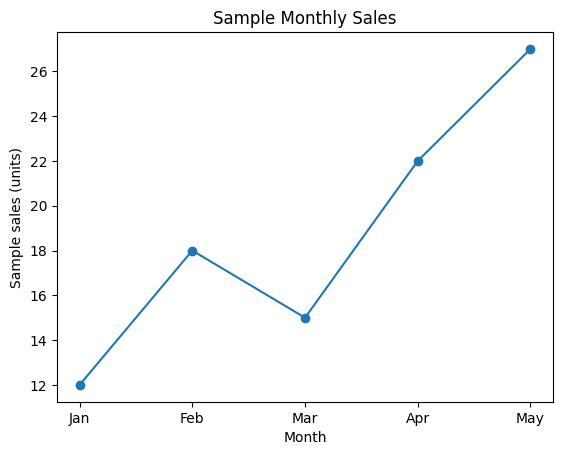

In [6]:
months = ["Jan", "Feb", "Mar", "Apr", "May"]
sample_sales = [12, 18, 15, 22, 27]

plt.plot(months, sample_sales, marker="o")
plt.xlabel("Month")
plt.ylabel("Sample sales (units)")
plt.title("Sample Monthly Sales")
plt.show()

The line chart connects illustrative monthly values to show how they change over time. Labels and a title make the chart easier to understand.

## 6. Seaborn

Seaborn is built on Matplotlib and provides a convenient interface for statistical graphics, especially with Pandas DataFrames.

**Three operations:** `sns.set_theme()` applies a theme, `sns.barplot()` compares category summaries, and `sns.histplot()` visualizes a numerical distribution.

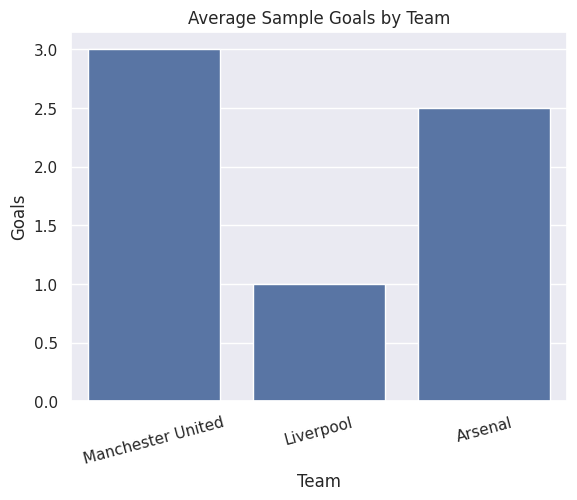

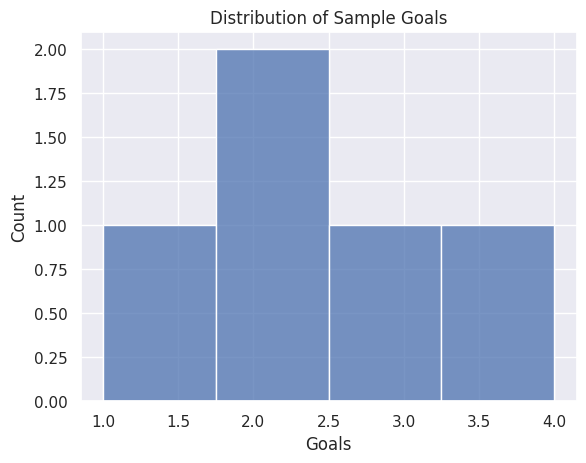

In [7]:
sns.set_theme()

sample_df = pd.DataFrame({
    "Team": ["Manchester United", "Liverpool", "Arsenal",
             "Manchester United", "Arsenal"],
    "Goals": [2, 1, 3, 4, 2]
})

# 1. Apply theme; 2. Create a bar plot
sns.barplot(data=sample_df, x="Team", y="Goals", errorbar=None)
plt.title("Average Sample Goals by Team")
plt.xticks(rotation=15)
plt.show()

# 3. Create a histogram
sns.histplot(data=sample_df, x="Goals", bins=4)
plt.title("Distribution of Sample Goals")
plt.show()

The bar plot compares average goals in a tiny illustrative dataset; the histogram shows the frequency of goal counts. These are made-up examples for demonstrating the functions, not official football statistics.

## 7. Loading the Titanic Dataset

The notebook first checks for `EDA/data/titanic.csv`. If it is not present, it reads the public CSV from the Seaborn example-data repository. Internet access is required for the fallback. If offline, download the CSV and place it in `EDA/data/`.

In [8]:
from pathlib import Path

data_path = Path("data/titanic.csv")

if data_path.exists():
    titanic = pd.read_csv(data_path)
    print(f"Loaded local dataset: {data_path}")
else:
    dataset_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
    titanic = pd.read_csv(dataset_url)
    print("Loaded Titanic dataset from the Seaborn example-data repository.")

print("Dataset loaded successfully.")

Loaded Titanic dataset from the Seaborn example-data repository.
Dataset loaded successfully.


## 8. Understanding the Dataset

Pandas provides several methods and attributes to inspect data before analysis.

### 8.1 `head()`

Displays the first five rows by default, helping us preview the records.

In [9]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### 8.2 `tail()`

Displays the last five rows by default, helping us inspect the end of the dataset.

In [10]:
titanic.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


### 8.3 `shape`

Returns a tuple containing the number of rows and columns.

In [11]:
print("Rows:", titanic.shape[0])
print("Columns:", titanic.shape[1])
print("Shape:", titanic.shape)

Rows: 891
Columns: 15
Shape: (891, 15)


### 8.4 `columns`

Displays all column names in the DataFrame.

In [12]:
print(titanic.columns.tolist())

['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


### 8.5 `info()`

Displays column names, non-null counts, data types and memory usage. It helps identify missing values and review data types.

In [13]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


### 8.6 `describe()`

Generates descriptive statistics for numerical columns, including count, mean, standard deviation, minimum, quartiles and maximum.

In [14]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


To include categorical columns, use `include="all"`. Not every statistic applies to every data type.

In [15]:
titanic.describe(include="all")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 9. Initial Observations

After running the inspection cells, write brief observations in your own words:

1. How many rows and columns are present?
2. Which columns are numerical?
3. Which columns are categorical or text?
4. Which columns appear to contain missing values?
5. What do the summary statistics suggest about passenger ages and fares?

A detailed cleaning process and EDA will follow in the next practical.

## Conclusion

This practical introduced four essential data-analysis libraries, demonstrated key operations, and loaded the Titanic dataset with Pandas. We used `head()`, `tail()`, `shape`, `columns`, `info()` and `describe()` to inspect its structure and summary statistics, preparing for data cleaning and EDA.